# 02. End-to-End Graph Flow 테스트

이 노트북은 사용자 질문 1개가 입력되면 LangGraph의 전체 흐름을 거쳐  
최종 응답이 생성되기까지의 과정을 보여준다.

## 흐름
```
사용자 질문
  └── planner_node  ← PlannerService가 query_type, steps 결정
       └── route_by_query_type  ← DB / RAG / GENERAL 분기
            ├── DB 경로: generate_sql → validate_sql → execute_sql → summarize_db
            │    └── DB_THEN_RAG: retrieve_rag → final_answer
            │    └── 기타: final_answer
            ├── RAG 경로: retrieve_rag → final_answer
            └── GENERAL 경로: general_answer → final_answer
```

## 실행 전 준비사항
- `config/config.yaml` 설정 확인
- Ollama 서버 또는 OpenAI API 준비
- DB 연결 또는 벡터스토어 필요 (DB/RAG 경로 테스트 시)

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"프로젝트 루트: {project_root}")

프로젝트 루트: c:\Users\김민한\Desktop\개발\DB_TO_LLM-main\DB_TO_LLM-main


## 그래프 구조 시각화

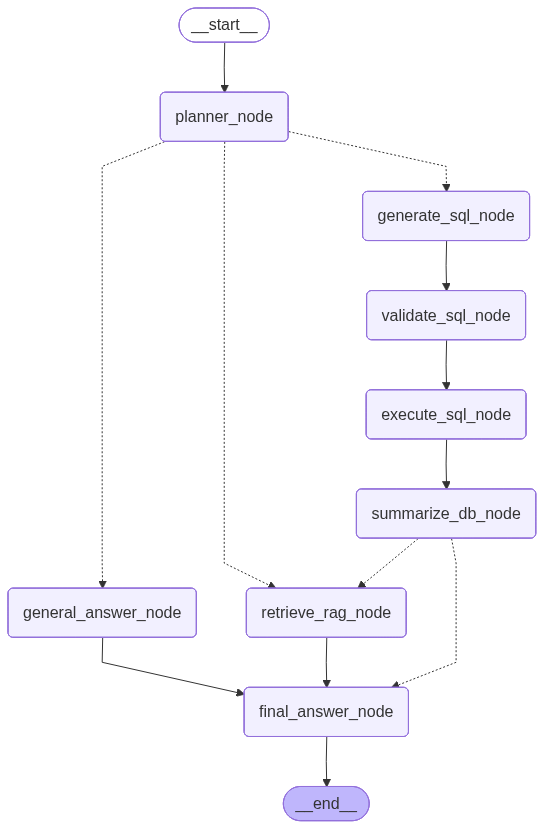


그래프 노드 목록:
  - __start__
  - planner_node
  - generate_sql_node
  - validate_sql_node
  - execute_sql_node
  - summarize_db_node
  - retrieve_rag_node
  - general_answer_node
  - final_answer_node
  - __end__


In [9]:
from src.db_to_llm.stream.graph.builder import build_graph

graph = build_graph()

# Mermaid 다이어그램 출력 시도
try:
    mermaid_png = graph.get_graph().draw_mermaid_png()
    from IPython.display import Image, display
    display(Image(mermaid_png))
except Exception as e:
    print(f"다이어그램 렌더링 실패 (선택 사항): {e}")

# 노드 목록
print("\n그래프 노드 목록:")
for node in graph.get_graph().nodes:
    print(f"  - {node}")

## 테스트 1: GENERAL 질문 (외부 의존성 없음)

In [10]:
import json
from src.db_to_llm.stream.graph.runner import run_graph

config_path = str(project_root / "config" / "config.yaml")

question_general = "파이썬에서 제너레이터(generator)란 무엇인가요?"
print(f"질문: {question_general}")
print("=" * 60)

result = run_graph(question=question_general, config_path=config_path)

print(f"query_type   : {result.get('query_type')}")
print(f"planner_plan :\n{json.dumps(result.get('planner_result', {}), ensure_ascii=False, indent=2)}")
print(f"\n최종 답변:")
print(result.get('final_answer', '(없음)'))

질문: 파이썬에서 제너레이터(generator)란 무엇인가요?
query_type   : GENERAL
planner_plan :
{
  "is_composite": false,
  "query_type": "GENERAL",
  "steps": [
    {
      "step": 1,
      "type": "general",
      "goal": "파이썬에서 제너레이터(generator)에 대한 개념을 설명한다.",
      "depends_on": []
    }
  ]
}

최종 답변:
파이썬의 제너레이터는 함수 내부에 yield 문을 사용하여 순환 가능한 객체를 생성하는 기법입니다. 이는 큰 데이터셋을 처리할 때 메모리를 효율적으로 사용할 수 있게 해주며, 일회성(iterable) 시퀀스를 만들 때 유용합니다.


## 테스트 2: trace_logs 및 errors 확인

In [11]:
print("\n=== 실행 추적 로그 ===")
for log in result.get("trace_logs", []):
    print(f"  {log}")

if result.get("errors"):
    print("\n=== 오류 목록 ===")
    for err in result["errors"]:
        print(f"  [오류] {err}")


=== 실행 추적 로그 ===
  [10:08:40] planner_node: query_type=GENERAL
  [10:08:43] general_answer_node: answer_length=128
  [10:08:43] final_answer_node: GENERAL 경로 완료


## 테스트 3: DB_ONLY 질문 (DB 연결 필요)

In [12]:

import pandas as pd

# DB 연결 설정이 되어있는 경우에만 실행
# config.yaml의 database 섹션에 올바른 연결 정보가 있어야 함

question_db = "최근 발생한 경고 종류 조회해줘"
print(f"질문: {question_db}")
print("=" * 60)

result_db = run_graph(question=question_db, config_path=config_path)

# ── 1) Planner 결과 ──────────────────────────────────────
print(f"[Planner] query_type: {result_db.get('query_type')}")

# ── 2) 생성된 SQL ────────────────────────────────────────
generated = result_db.get("generated_sql")
validated = result_db.get("validated_sql")
sql_passed = result_db.get("sql_validation_passed")
sql_error  = result_db.get("sql_validation_error")

if generated:
    print("\n[생성된 SQL]")
    print("-" * 40)
    print(generated)
    print("-" * 40)
    print(f"  검증 통과: {sql_passed}")
    if not sql_passed and sql_error:
        print(f"  검증 오류: {sql_error}")

# ── 3) SQL 실행 결과 (표) ────────────────────────────────
db_rows    = result_db.get("db_rows", [])
db_columns = result_db.get("db_columns", [])
row_count  = result_db.get("db_row_count", len(db_rows))

print(f"\n[SQL 실행 결과]  총 {row_count}행")
if db_rows:
    # db_columns가 없으면 첫 행의 키를 컬럼으로 사용
    if not db_columns and isinstance(db_rows[0], dict):
        db_columns = list(db_rows[0].keys())
    df = pd.DataFrame(db_rows, columns=db_columns if db_columns else None)
    display(df)
else:
    print("  (결과 없음)")

# ── 4) DB 요약 & 최종 답변 ───────────────────────────────
if result_db.get("db_summary"):
    print(f"\n[DB 요약]\n{result_db['db_summary']}")

print(f"\n[최종 답변]\n{result_db.get('final_answer', '(없음)')}")


질문: 최근 발생한 경고 종류 조회해줘
[Planner] query_type: DB_ONLY

[생성된 SQL]
----------------------------------------
```sql
SELECT TOP 100 ALARMID, ALARMTEXT, ACTION, EVENTTIME 
FROM WARNING_LOG_DATA
ORDER BY EVENTTIME DESC
```
----------------------------------------
  검증 통과: True

[SQL 실행 결과]  총 100행


,ALARMID,ALARMTEXT,ACTION,EVENTTIME
0,16,XB01_DOWNSTREAM_TRANSFER_STOP,RESET,2026-04-11T19:23:16.499000
1,15,XB01_DOWNSTREAM_LOADING_STOP,RESET,2026-04-11T19:23:15.600000
2,16,XB01_DOWNSTREAM_TRANSFER_STOP,RESET,2026-04-11T19:23:09.596000
3,15,XB01_DOWNSTREAM_LOADING_STOP,RESET,2026-04-11T19:23:08.674000
4,16,XB01_DOWNSTREAM_TRANSFER_STOP,RESET,2026-04-11T19:22:55.772000
...,...,...,...,...
95,16,XB01_DOWNSTREAM_TRANSFER_STOP,SET,2026-04-11T19:13:52.053000
96,16,XB01_DOWNSTREAM_TRANSFER_STOP,RESET,2026-04-11T19:13:51.040000
97,15,XB01_DOWNSTREAM_LOADING_STOP,RESET,2026-04-11T19:13:50.083000
98,16,XB01_DOWNSTREAM_TRANSFER_STOP,RESET,2026-04-11T19:13:38.603000



[DB 요약]
데이터베이스에서 조회된 전체 행은 100개이며, 주요 알람 내용은 "XB01_DOWNSTREAM_TRANSFER_STOP"과 "XB01_DOWNSTREAM_LOADING_STOP"으로 동일한 ID와 텍스트의 알람이 반복적으로 발생하고 있다. 이들 알람 모두 'RESET' 액션을 취했으며, 가장 최근 알람 시간은 2026년 4월 11일 19시 23분이며, 가장 오래된 알람 시간은 해당 날짜의 19시 20분이다.

[최종 답변]
최근 발생한 경보의 종류는 "XB01_DOWNSTREAM_TRANSFER_STOP"과 "XB01_DOWNSTREAM_LOADING_STOP" 두 가지입니다. 이 알람들은 모두 동일한 ID와 텍스트를 가지고 있으며, 'RESET' 액션을 취했습니다. 가장 최근 알림은 2026년 4월 11일 19시 23분에 발생했으며, 가장 오래된 알림은 같은 날 19시 20분으로 확인되었습니다. 이 외 추가적인 정보는 없습니다.


## 테스트 4: RAG_ONLY 질문 (벡터스토어 필요)

In [13]:
# notebooks/ingest/01_build_vectorstore.ipynb를 먼저 실행하여
# ChromaDB에 문서가 업로드되어 있어야 한다

question_rag = "최근 발생한 경고 종류 조회하고 발생했을 때 어떻게 처리해야 하나요?"
print(f"질문: {question_rag}")
print("=" * 60)

result_rag = run_graph(question=question_rag, config_path=config_path)

print(f"query_type       : {result_rag.get('query_type')}")
print(f"검색된 컨텍스트 수: {len(result_rag.get('retrieved_contexts', []))}")

for i, ctx in enumerate(result_rag.get("retrieved_contexts", [])[:3], 1):
    print(f"\n[컨텍스트 {i}]")
    print(f"  source: {ctx.get('source', 'N/A')}")
    snippet = ctx.get('text', '')[:200]
    print(f"  text  : {snippet}...")

print(f"\n최종 답변:\n{result_rag.get('final_answer', '(없음)')}")

질문: 최근 발생한 경고 종류 조회하고 발생했을 때 어떻게 처리해야 하나요?
query_type       : DB_THEN_RAG
검색된 컨텍스트 수: 0

최종 답변:
2026년 4월 11일에 주요 경보가 발생했는데, "XB01_DOWNSTREAM_TRANSFER_STOP"과 "XB01_DOWNSTREAM_LOADING_STOP"이 가장 많이 나타났습니다. 이 알람들은 정확하게 1분 간격으로 시간대별로 발생했습니다. 이러한 알람이 발생했을 때는 'RESET' 또는 'SET'으로 처리하면 됩니다. 하지만 자세한 조치 방법에 대한 추가 정보가 부족합니다. 더 구체적인 해결 방안은 제공된 문서나 데이터베이스에서 찾을 수 없으니, 관련 전문가에게 문의하시는 것이 좋겠습니다.


## 테스트 5: DB_THEN_RAG 질문 (DB 연결 + 벡터스토어 필요)

DB를 먼저 조회한 뒤, 그 결과를 바탕으로 RAG 문서까지 검색해 최종 답변을 생성하는 흐름이다.

```
generate_sql → validate_sql → execute_sql → summarize_db → retrieve_rag → final_answer
```


In [ ]:
import pandas as pd
from IPython.display import display

# DB 조회와 RAG 검색이 모두 필요한 질문
question_db_rag = "최근 발생한 경고 로그를 조회하고, 각 경고에 대한 처리 방법도 알려줘"
print(f"질문: {question_db_rag}")
print("=" * 60)

result_db_rag = run_graph(question=question_db_rag, config_path=config_path)

# ── 1) Planner 결과 ──────────────────────────────────────
print(f"[Planner] query_type: {result_db_rag.get('query_type')}")

# ── 2) 생성된 SQL ────────────────────────────────────────
generated_dr = result_db_rag.get("generated_sql")
sql_passed_dr = result_db_rag.get("sql_validation_passed")
sql_error_dr  = result_db_rag.get("sql_validation_error")

if generated_dr:
    print("\n[생성된 SQL]")
    print("-" * 40)
    print(generated_dr)
    print("-" * 40)
    print(f"  검증 통과: {sql_passed_dr}")
    if not sql_passed_dr and sql_error_dr:
        print(f"  검증 오류: {sql_error_dr}")
else:
    print("\n[생성된 SQL] (없음)")

# ── 3) SQL 실행 결과 (표) ────────────────────────────────
db_rows_dr    = result_db_rag.get("db_rows", [])
db_columns_dr = result_db_rag.get("db_columns", [])
row_count_dr  = result_db_rag.get("db_row_count", len(db_rows_dr))

print(f"\n[SQL 실행 결과]  총 {row_count_dr}행")
if db_rows_dr:
    if not db_columns_dr and isinstance(db_rows_dr[0], dict):
        db_columns_dr = list(db_rows_dr[0].keys())
    df_dr = pd.DataFrame(db_rows_dr, columns=db_columns_dr if db_columns_dr else None)
    display(df_dr)
else:
    print("  (결과 없음)")

# ── 4) DB 요약 ───────────────────────────────────────────
if result_db_rag.get("db_summary"):
    print(f"\n[DB 요약]\n{result_db_rag['db_summary']}")

# ── 5) RAG 검색 컨텍스트 ─────────────────────────────────
contexts_dr = result_db_rag.get("retrieved_contexts", [])
print(f"\n[RAG 검색 결과]  총 {len(contexts_dr)}개 컨텍스트")
for i, ctx in enumerate(contexts_dr[:3], 1):
    print(f"\n  [컨텍스트 {i}]")
    print(f"    source : {ctx.get('source', 'N/A')}")
    snippet = ctx.get('text', '')[:200]
    print(f"    text   : {snippet}...")

# ── 6) 최종 답변 ─────────────────────────────────────────
print(f"\n[최종 답변]\n{result_db_rag.get('final_answer', '(없음)')}")

# ── 7) 실행 로그 / 오류 ──────────────────────────────────
print("\n=== 실행 추적 로그 ===")
for log in result_db_rag.get("trace_logs", []):
    print(f"  {log}")

if result_db_rag.get("errors"):
    print("\n=== 오류 목록 ===")
    for err in result_db_rag["errors"]:
        print(f"  [오류] {err}")


질문: 최근 발생한 경고 로그를 조회하고, 각 경고에 대한 처리 방법도 알려줘


## 테스트 6: API 서버 연동 테스트 (선택 사항)

In [ ]:
# API 서버 실행 명령 (외부 접속 허용):
# uvicorn src.db_to_llm.stream.api.app:app --reload --host 0.0.0.0 --port 8000

# 아래는 서버가 실행 중일 때만 동작한다
SERVER_HOST = "localhost"  # 외부 머신에서 접속 시 실제 서버 IP로 변경
SERVER_PORT = 8000

try:
    import requests
    response = requests.post(
        f"http://{SERVER_HOST}:{SERVER_PORT}/api/query",
        json={"question": "파이썬이란 무엇인가요?"},
        timeout=60
    )
    if response.status_code == 200:
        data = response.json()
        print(f"query_type: {data.get('query_type')}")
        print(f"최종 답변 :\n{data.get('final_answer', '(없음)')}")
    else:
        print(f"서버 오류: {response.status_code} - {response.text}")
except Exception as e:
    print(f"API 서버 연결 실패 (서버가 실행 중인지 확인): {e}")


query_type: GENERAL
최종 답변 :
파이썬은 프로그래밍 언어 중 하나로, 사용하기 쉽고 다양한 분야에서 활용됩니다.
